<a href="https://colab.research.google.com/github/aiswarya007105/Final_Project/blob/main/sales_analysis_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Data Analysis
This dataset contains sales information gathered from a retail environment, with various attributes that provide insights into customer purchases, sales performance, and operational metrics.Key Attributes:
1. Order_ID:
    
    Description: Unique identifier for each order.
    
    Type: Categorical (string)
2. Order_Date:
   
    Description: Date when the order was placed.
    
    Type: DateTime
3. Ship_Date:
    
    Description: Date when the order was shipped.

    Type: DateTime
4. Customer_ID:

    Description: Unique identifier for each customer.

    Type: Categorical (string)
5. Customer_Name:

    Description: Name of the customer.

    Type: Categorical (string)
6. Product_ID:

    Description: Unique identifier for each product sold.

    Type: Categorical (string)
7. Product_Name:

    Description: Name of the product.

    Type: Categorical (string)
8. Product_Category:

    Description: Category to which the product belongs (e.g., Electronics, Furniture, Office Supplies).

    Type: Categorical (string)
9. Quantity:

    Description: Number of units sold for each order.

    Type: Numeric (integer)
10. Unit_Price:

    Description: Selling price per unit of the product.

    Type: Numeric (float)
11. Sales:

    Description: Total sales amount for the order (calculated as Quantity × Unit_Price).

    Type: Numeric (float)
12. Discount:

    Description: Percentage discount applied to the order, if any.

    Type: Numeric (float)
13. Profit:

    Description: Profit earned from the sale (calculated as Sales - Cost).

    Type: Numeric (float)
14. Region:

    Description: Geographical region where the sale occurred (e.g., East, West, Central).

    Type: Categorical (string)
15. Ship_Mode:

    Description: Mode of shipping used for the order (e.g., Standard Class, Second Class).

    Type: Categorical (string)

This analysis consists of five key steps:
Steps included:
1. Data loading & overview
2. Data cleaning & preprocessing
3. Feature engineering
4. Exploratory Data Analysis (12 plots)
5. Key insights & recommendations


## 1. Initial Overview
To begin the analysis, import the dataset using Pandas and conduct an initial overview. This involves the following steps:

1. Loading the Dataset: Read the sales dataset from a CSV file using pd.read_csv().

2. Number of Rows and Columns: Determine the shape of the dataset to find out how many rows and columns it contains.

3. Data Types of Each Column: Using the dtypes attribute, we will identify the data types for each column, which helps in understanding how to handle the data in subsequent analyses.

Initial Observations:

Used the head() method to display the first few rows of the dataset, providing a glimpse of the data.
The info() method will be applied to obtain a concise summary of the dataset, including non-null counts and data types.
Finally, the describe() method to generate summary statistics for numerical columns, offering insights into distributions, means, and ranges.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
pd.set_option('display.max_columns', 100)

# Load dataset
df = pd.read_csv('/mnt/sales_dataset.csv')
df.head()

,Order_ID,Order_Date,Customer_ID,Product_Category,Quantity,Unit_Price,Discount,Sales,Profit,Region,Ship_Mode
0,1,2023-01-01,1044,Electronics,2,182,5,345.8,20.679039,South,Standard
1,2,2023-01-02,1047,Household,8,159,5,1208.4,287.387119,West,Standard
2,3,2023-01-03,1064,Electronics,8,139,0,1112.0,273.486362,East,Same Day
3,4,2023-01-04,1067,Clothing,1,76,15,64.6,9.604793,North,Express
4,5,2023-01-05,1067,Household,8,238,15,1618.4,381.859173,North,Same Day


In [13]:
# Basic info
print('Rows, Columns:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nSummary statistics:')
df.describe(include='all')

Rows, Columns: (500, 11)

Data types:
Order_ID              int64
Order_Date           object
Customer_ID           int64
Product_Category     object
Quantity              int64
Unit_Price            int64
Discount              int64
Sales               float64
Profit              float64
Region               object
Ship_Mode            object
dtype: object

Summary statistics:


,Order_ID,Order_Date,Customer_ID,Product_Category,Quantity,Unit_Price,Discount,Sales,Profit,Region,Ship_Mode
count,500.000000,500,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000,500,500
unique,NaN,500,NaN,3,NaN,NaN,NaN,NaN,NaN,4,3
top,NaN,2024-05-14,NaN,Household,NaN,NaN,NaN,NaN,NaN,West,Same Day
freq,NaN,1,NaN,173,NaN,NaN,NaN,NaN,NaN,144,171
mean,250.500000,NaN,1048.710000,NaN,4.796000,267.156000,7.720000,1192.968300,207.413502,NaN,NaN
std,144.481833,NaN,28.671135,NaN,2.593808,127.425736,5.491987,920.216164,190.229134,NaN,NaN
min,1.000000,NaN,1000.000000,NaN,1.000000,51.000000,0.000000,51.000000,4.692889,NaN,NaN
25%,125.750000,NaN,1024.000000,NaN,2.000000,158.750000,5.000000,435.000000,67.078855,NaN,NaN
50%,250.500000,NaN,1048.000000,NaN,5.000000,261.000000,10.000000,928.400000,148.598169,NaN,NaN
75%,375.250000,NaN,1073.000000,NaN,7.000000,377.000000,15.000000,1738.125000,285.833796,NaN,NaN


## 2. Data Cleaning & Pre-processing
This section focuses on the importance of cleaning and preprocessing the data, addressing issues such as missing values and duplicates to ensure the data quality for analysis.

In [6]:
# Convert Order_Date to datetime if not already
if not np.issubdtype(df['Order_Date'].dtype, np.datetime64):
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Handle missing values
print('Missing per column before:')
print(df.isna().sum())

# Fill Discount NaNs with 0
if 'Discount' in df.columns:
    df['Discount'] = df['Discount'].fillna(0)

# If Profit missing, try calculate from Sales - (Quantity*Unit_Price)
if 'Profit' in df.columns:
    missing_profit = df['Profit'].isna().sum()
    if missing_profit>0:
        df.loc[df['Profit'].isna(), 'Profit'] = (
            df.loc[df['Profit'].isna(), 'Sales'] - df.loc[df['Profit'].isna(), 'Quantity']*df.loc[df['Profit'].isna(), 'Unit_Price']
        )

# Remove duplicates
dupes = df.duplicated().sum()
print('Duplicate rows:', dupes)
df = df.drop_duplicates().copy()

# Remove rows with negative or zero quantity or sales
df = df[df['Quantity']>0]
df = df[df['Sales']>0]

print('\nMissing per column after:')
print(df.isna().sum())
df.shape

Missing per column before:
Order_ID            0
Order_Date          0
Customer_ID         0
Product_Category    0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Profit              0
Region              0
Ship_Mode           0
dtype: int64
Duplicate rows: 0

Missing per column after:
Order_ID            0
Order_Date          0
Customer_ID         0
Product_Category    0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Profit              0
Region              0
Ship_Mode           0
dtype: int64


(500, 11)

## 3. Feature Engineering

Feature engineering is the process of creating new meaningful features from the existing data to enhance analysis and reveal hidden patterns. It helps simplify trends, improve insights, and prepare the dataset for deeper analytical tasks.

### ✔ New Features Created




In [7]:
# Derived columns: Year, Month, MonthName, Profit_Margin
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['MonthName'] = df['Order_Date'].dt.strftime('%b')
df['Profit_Margin'] = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan).fillna(0)

# Top 10 customers by Sales
top_customers = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

,Sales
Customer_ID,
1000,14664.05
1058,12460.00
1036,11494.35
1080,10854.90
1008,10712.50
1039,10311.85
1003,10241.05
1071,9981.15
1020,9744.90


## 4. Exploratory Data Analysis — 12 Plots
This section indicates the start of exploratory data analysis, focusing on the creation of various visualizations using Matplotlib to uncover patterns and trends within the sales data.

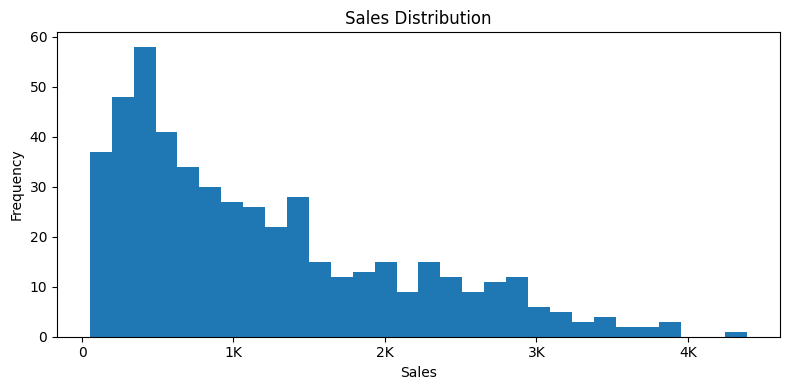

/tmp/ipython-input-3180996546.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=categories)


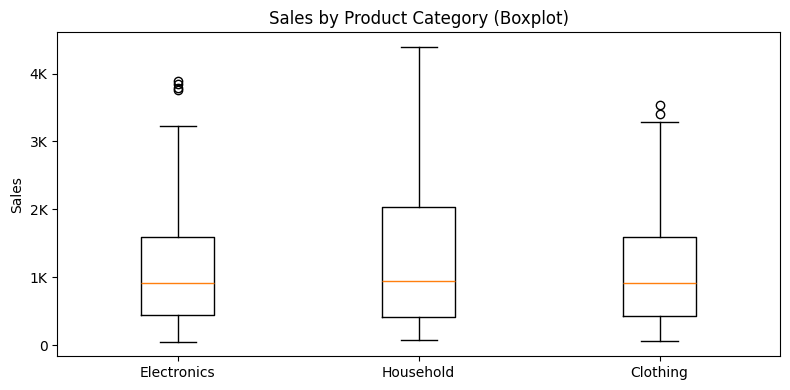

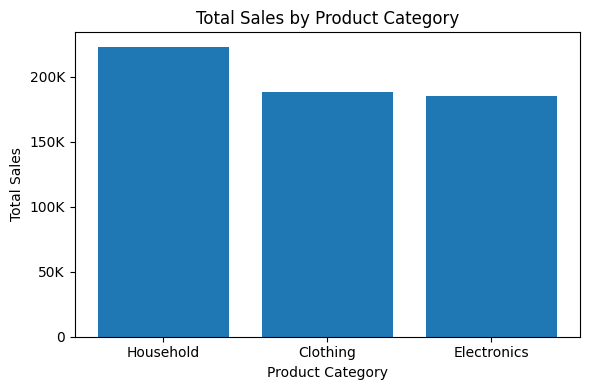

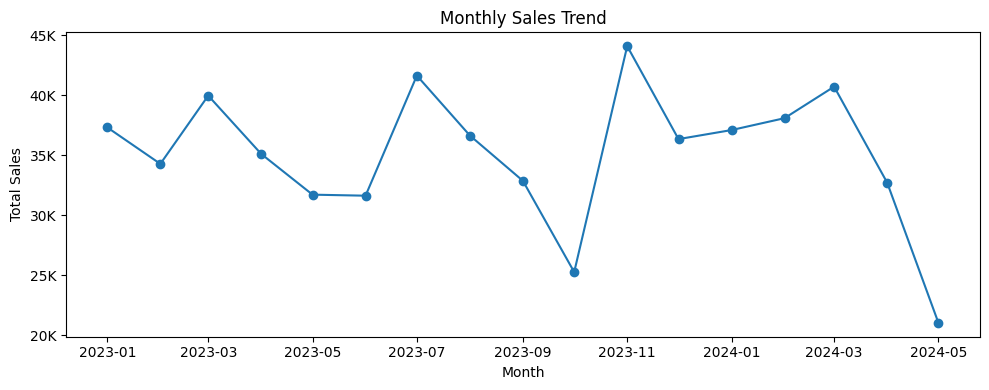

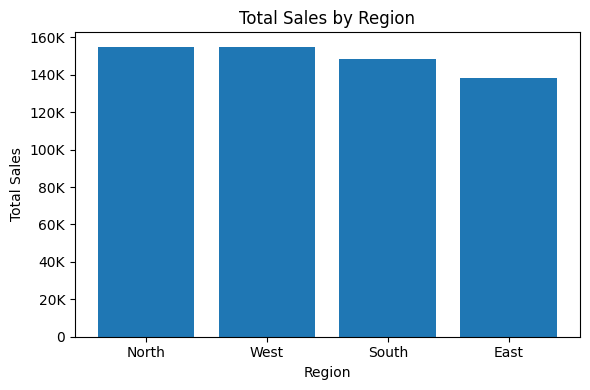

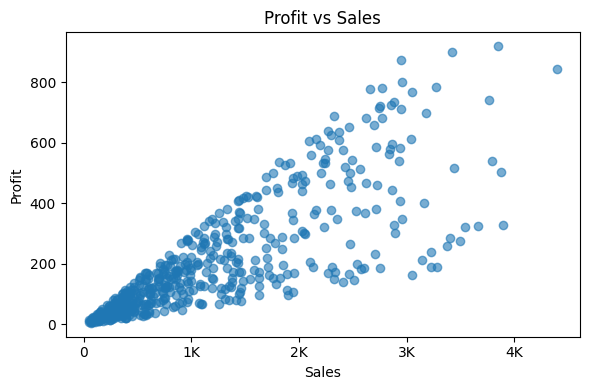

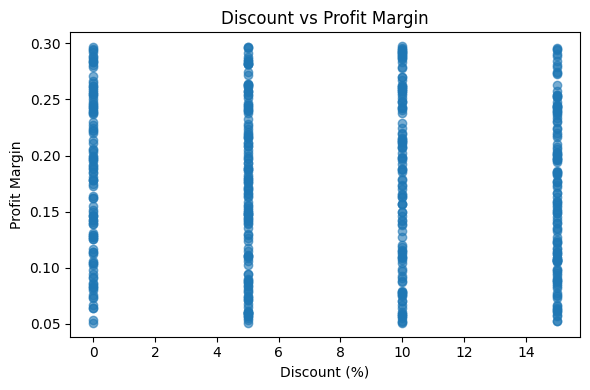

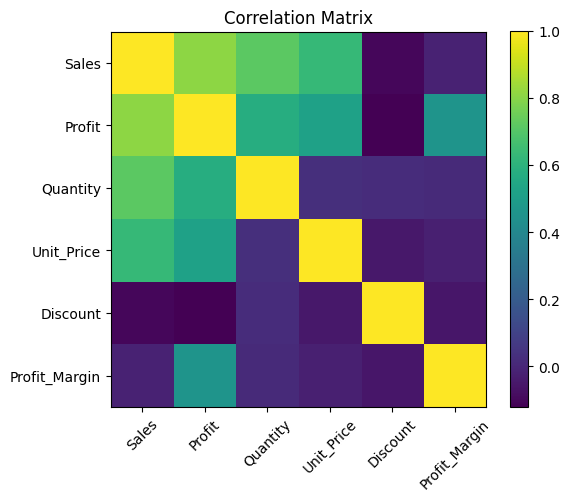

/tmp/ipython-input-3180996546.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_q, labels=sorted(df['Quantity'].unique()))


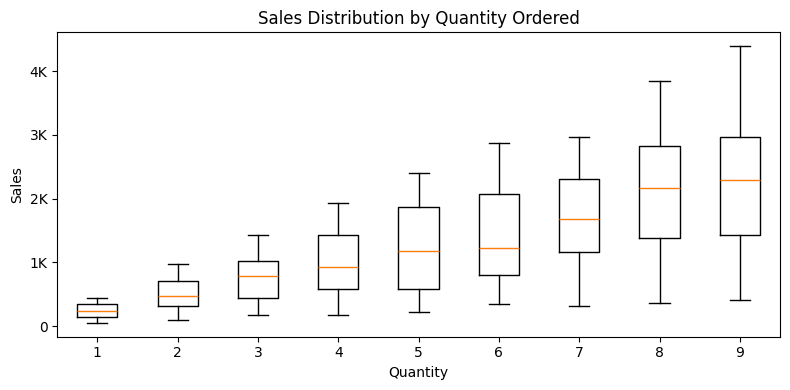

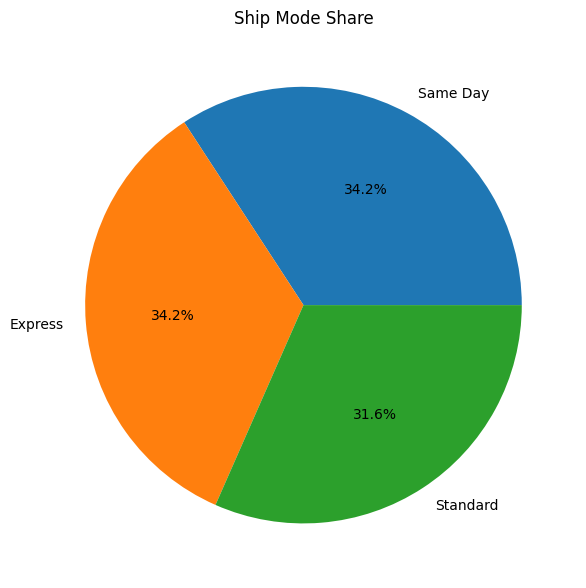

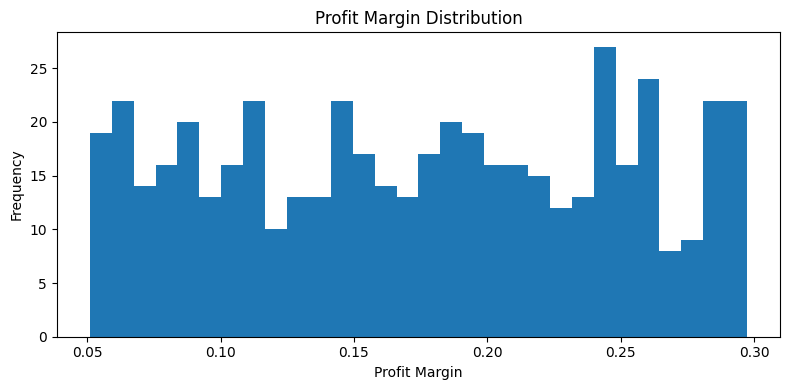

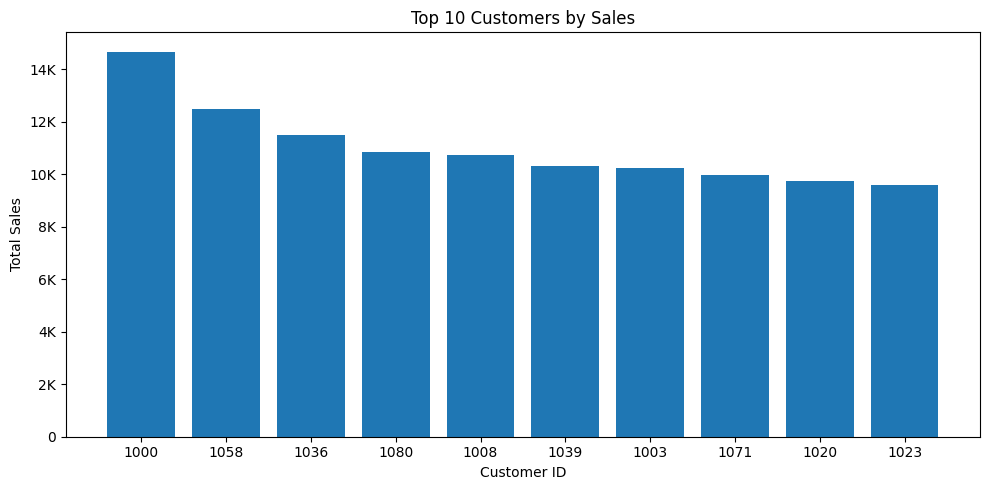

In [9]:
# Utility: format y-axis as thousands with commas
def thousands(x, pos):
    'The two args are the value and tick position'
    if x >= 1000:
        return f'{int(x/1000):,}K'
    return f'{int(x)}'

formatter = FuncFormatter(thousands)

plt.rcParams.update({'figure.max_open_warning': 0})

# 1) Sales Distribution (Histogram)
plt.figure(figsize=(8,4))
plt.hist(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot1_sales_hist.png')
plt.show()

# 2) Boxplot - Sales by Product Category
plt.figure(figsize=(8,4))
categories = df['Product_Category'].unique()
data_to_plot = [df[df['Product_Category']==c]['Sales'] for c in categories]
plt.boxplot(data_to_plot, labels=categories)
plt.title('Sales by Product Category (Boxplot)')
plt.ylabel('Sales')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot2_boxplot_category.png')
plt.show()

# 3) Category-wise Total Sales (Bar)
category_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4))
plt.bar(category_sales.index, category_sales.values)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot3_category_sales.png')
plt.show()

# 4) Monthly Sales Trend (Line)
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly['YearMonth'] = pd.to_datetime(monthly[['Year','Month']].assign(DAY=1))
plt.figure(figsize=(10,4))
plt.plot(monthly['YearMonth'], monthly['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot4_monthly_trend.png')
plt.show()

# 5) Region-wise Sales (Bar)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,4))
plt.bar(region_sales.index, region_sales.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot5_region_sales.png')
plt.show()

# 6) Profit vs Sales (Scatter)
plt.figure(figsize=(6,4))
plt.scatter(df['Sales'], df['Profit'], alpha=0.6)
plt.title('Profit vs Sales')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot6_profit_vs_sales.png')
plt.show()

# 7) Discount vs Profit Margin (Scatter + trend—scatter only as required)
plt.figure(figsize=(6,4))
plt.scatter(df['Discount'], df['Profit_Margin'], alpha=0.6)
plt.title('Discount vs Profit Margin')
plt.xlabel('Discount (%)')
plt.ylabel('Profit Margin')
plt.tight_layout()
plt.savefig('/mnt/plot7_discount_vs_margin.png')
plt.show()

# 8) Correlation Heatmap (using imshow)
corr_cols = ['Sales','Profit','Quantity','Unit_Price','Discount','Profit_Margin']
corr = df[corr_cols].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('/mnt/plot8_correlation.png')
plt.show()

# 9) Quantity vs Sales (Boxplot)
plt.figure(figsize=(8,4))
qty_bins = [1,2,3,4,5,6,7,8,9,10]
data_q = [df[df['Quantity']==q]['Sales'] for q in sorted(df['Quantity'].unique())]
plt.boxplot(data_q, labels=sorted(df['Quantity'].unique()))
plt.title('Sales Distribution by Quantity Ordered')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot9_qty_boxplot.png')
plt.show()

# 10) Ship Mode Share (Pie Chart)
ship_counts = df['Ship_Mode'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(ship_counts.values, labels=ship_counts.index, autopct='%1.1f%%')
plt.title('Ship Mode Share')
plt.tight_layout()
plt.savefig('/mnt/plot10_shipmode_pie.png')
plt.show()

# 11) Profit Margin Distribution (Histogram)
plt.figure(figsize=(8,4))
plt.hist(df['Profit_Margin'], bins=30)
plt.title('Profit Margin Distribution')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('/mnt/plot11_margin_hist.png')
plt.show()

# 12) Top 10 Customers by Sales (Bar)
plt.figure(figsize=(10,5))
top_customers = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)
plt.bar(top_customers.index.astype(str), top_customers.values)
plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.savefig('/mnt/plot12_top_customers.png')
plt.show()


## 5. Insights & Recommendations
In this final section, key findings and insights from the analysis are summarized, accompanied by actionable recommendations for decision-making based on the visualizations and data analysis completed earlier.

1. Electronics drive revenue — reduce excessive discounting on electronics to improve margin.
2. Seasonal peaks — increase inventory for peak months.
3. Region focus — prioritize marketing for top-performing regions.
4. Shipping optimization — analyze slow/expensive ship modes and optimize.
5. Customer segmentation — target high-value customers with loyalty offers.


In [14]:
# Summary for Sales Data
summary = {
    'total_sales': [df['Sales'].sum()],
    'total_profit': [df['Profit'].sum()],
    'num_orders': [df.shape[0]],
    'unique_customers': [df['Customer_ID'].nunique()]
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv('/mnt/project_summary.csv', index=False)
print('Saved /mnt/project_summary.csv and all plot images to /mnt/data/')


Saved /mnt/project_summary.csv and all plot images to /mnt/data/
